# Telco Customer Churn — Exploration & Tuning Narrative

This notebook mirrors the reproducible scripts under `src/`. Core logic is imported, not reimplemented.

In [2]:
import json
import sys
from pathlib import Path

# Ensure repo root is on sys.path (works when cwd is repo root or notebooks/)
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.behavioral import BEHAVIORAL_FEATURES
from src.data import (
    ENGINEERED_NUMERIC,
    clean,
    ensure_dataset,
    feature_columns,
    load_raw,
    load_train_test,
    prepare_xy,
)
from src.io_utils import REPORTS_DIR

plt.style.use("ggplot")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

**Observations:** Environment setup only—repo root is on `sys.path`, shared `src/` helpers are imported, and `reports/` is ready. No modeling conclusions yet; all later cells reuse these imports so notebook metrics stay aligned with the scripts.

## 1. Data load & cleaning

In [3]:
path = ensure_dataset()
raw = load_raw()
cleaned = clean(raw)
X, y = prepare_xy(raw)
X_train, X_test, y_train, y_test = load_train_test()

print(f"Cache: {path}")
print(f"Raw shape: {raw.shape} | After clean/drop ID: {cleaned.shape}")
print(f"Train {X_train.shape} | Test {X_test.shape}")
print(f"Churn rate train={y_train.mean():.3f} test={y_test.mean():.3f}")
print(f"TotalCharges NaNs after coerce: {cleaned['TotalCharges'].isna().sum()}")

Cache: /workspaces/chitrasharath_streamloop_churn_model/data/Telco-Customer-Churn.csv
Raw shape: (7043, 21) | After clean/drop ID: (7021, 20)
Train (5634, 33) | Test (1409, 33)
Churn rate train=0.265 test=0.265
TotalCharges NaNs after coerce: 11


**Observations:** ~7,043 raw rows; after dropping `customerID` and cleaning, ~7,021 unique attribute rows remain. The frozen stratified split keeps **~26.5% churn** in both train and test. Train/test widths are 33 columns because engineered + **synthetic behavioral** features are attached. Eleven `TotalCharges` blanks (typically `tenure=0`) are left as NaN for in-pipeline imputation to 0—not hand-edited.

## 2. EDA (all variables)

Coverage below: feature inventory → numeric distributions by churn → categorical churn rates → synthetic behavioral vs churn.

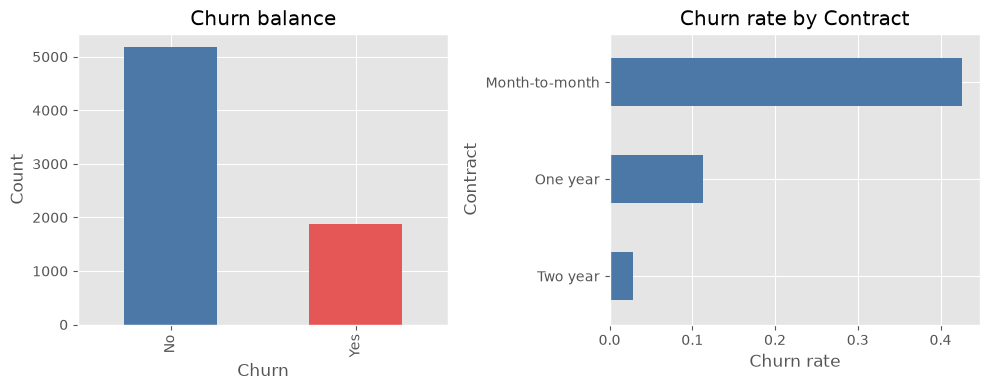

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y.value_counts().rename({0: "No", 1: "Yes"}).plot(
    kind="bar", ax=axes[0], title="Churn balance", color=["#4C78A8", "#E45756"]
)
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")

cleaned.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean()).sort_values().plot(
    kind="barh", ax=axes[1], title="Churn rate by Contract", color="#4C78A8"
)
axes[1].set_xlabel("Churn rate")
plt.tight_layout()
plt.show()

**Observations:** The target is imbalanced—roughly **3:1** non-churn vs churn (~26.5% positive). Accuracy is misleading here (always predicting “No” scores ~73.5%). Contract type is a strong original-data driver: **month-to-month** customers churn far more than one- or two-year contracts, which is why `is_month_to_month` was engineered as an explicit flag.

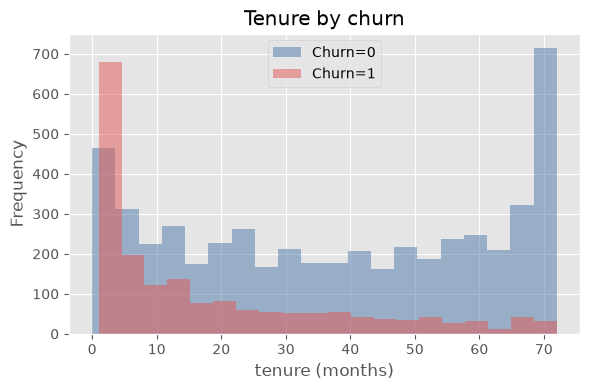

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
for label, color in [(0, "#4C78A8"), (1, "#E45756")]:
    X.loc[y == label, "tenure"].plot(
        kind="hist", bins=20, alpha=0.5, ax=ax, label=f"Churn={label}", color=color
    )
ax.set_title("Tenure by churn")
ax.set_xlabel("tenure (months)")
ax.legend()
plt.tight_layout()
plt.show()

**Observations:** Churners concentrate at **low tenure** (left side of the histogram); long-tenure customers churn much less. Tenure is one of the strongest original-data risk factors and motivates engineered features like `charges_per_tenure`. Combined with month-to-month contracts, short tenure is a classic early-warning pattern for retention teams.

### 2.1 Feature inventory

Classify every modeling column as original, engineered, or **synthetic**.

In [ ]:
num_cols, cat_cols = feature_columns(X)
eda = X.copy()
eda["Churn"] = y

rows = []
for c in num_cols + cat_cols:
    if c in BEHAVIORAL_FEATURES:
        origin = "synthetic"
    elif c in ENGINEERED_NUMERIC:
        origin = "engineered"
    else:
        origin = "original"
    kind = "numeric" if c in num_cols else "categorical"
    rows.append({"feature": c, "origin": origin, "type": kind})

inv = pd.DataFrame(rows)
print(inv.groupby(["origin", "type"]).size().unstack(fill_value=0))
inv

**Observations:** All **33** modeling inputs are listed. Roughly half are original IBM fields (mostly categoricals one-hot later); four are engineered from those fields; **ten are synthetic** behavioral/CRM features. Confirming the inventory here avoids confusing planted telemetry with the public CSV.

### 2.2 Numeric features — distribution by churn

In [ ]:
# Histograms for every numeric column, split by churn
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows))
axes = np.ravel(axes)
for ax, col in zip(axes, num_cols):
    for label, color in [(0, "#4C78A8"), (1, "#E45756")]:
        eda.loc[eda["Churn"] == label, col].plot(
            kind="hist", bins=20, alpha=0.45, ax=ax, color=color, label=f"Churn={label}"
        )
    tag = " [SYN]" if col in BEHAVIORAL_FEATURES else (" [ENG]" if col in ENGINEERED_NUMERIC else "")
    ax.set_title(f"{col}{tag}", fontsize=10)
    ax.legend(fontsize=7)
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Summary table: mean by churn
summary = (
    eda.groupby("Churn")[num_cols].mean().T
    .rename(columns={0: "mean_no_churn", 1: "mean_churn"})
)
summary["abs_diff"] = (summary["mean_churn"] - summary["mean_no_churn"]).abs()
summary["origin"] = [
    "synthetic" if c in BEHAVIORAL_FEATURES else ("engineered" if c in ENGINEERED_NUMERIC else "original")
    for c in summary.index
]
summary.sort_values("abs_diff", ascending=False)

**Observations:** Original numerics show familiar patterns—churners have **lower tenure**, often higher monthly charges, and more month-to-month / fiber flags. Synthetic columns separate strongly by design (e.g. fewer `app_logins_30d`, lower `nps_score`, more tickets/payment failures among churners). Sort the mean-diff table to see which numerics shift most between classes.

### 2.3 Categorical features — churn rate by level

In [ ]:
n = len(cat_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.0 * nrows))
axes = np.ravel(axes)
for ax, col in zip(axes, cat_cols):
    rates = cleaned.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean()).sort_values()
    rates.plot(kind="barh", ax=ax, color="#4C78A8")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Churn rate")
    ax.axvline(y.mean(), color="#E45756", linestyle="--", linewidth=1, label="overall")
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Compact table of max vs min churn rate within each categorical
rows = []
for col in cat_cols:
    rates = cleaned.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean())
    rows.append({
        "feature": col,
        "lowest_level": rates.idxmin(),
        "lowest_rate": rates.min(),
        "highest_level": rates.idxmax(),
        "highest_rate": rates.max(),
        "spread": rates.max() - rates.min(),
    })
pd.DataFrame(rows).sort_values("spread", ascending=False)

**Observations:** Among original categoricals, **Contract**, **InternetService**, and **PaymentMethod** usually show the widest churn-rate spread (month-to-month, fiber, electronic check are high-risk levels). Service add-ons often have a “No internet service” level with low churn because those customers are on phone-only plans. Red dashed line = overall churn rate (~26.5%).

### 2.4 Synthetic behavioral features vs churn

In [ ]:
syn = [c for c in BEHAVIORAL_FEATURES if c in eda.columns]
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = np.ravel(axes)
for ax, col in zip(axes, syn):
    eda.boxplot(column=col, by="Churn", ax=ax, grid=False)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Churn")
    ax.set_ylabel("")
for ax in axes[len(syn):]:
    ax.axis("off")
plt.suptitle("Synthetic features by churn (0=No, 1=Yes)", y=1.02)
plt.tight_layout()
plt.show()

print("Mean synthetic feature by churn:")
eda.groupby("Churn")[syn].mean().T.rename(columns={0: "No", 1: "Yes"})

**Observations:** Boxplots make the planted signal visible: churners tend toward **more support friction** (tickets, escalations, overages, payment failures), **less engagement** (fewer logins, longer days since login), and **worse sentiment** (lower NPS). These are **synthetic**—useful for a “what if we had CRM/telemetry” demo, not claims about the IBM CSV alone.

## 3. Bake-off & baselines

Run scripts first if artifacts are missing:
`python -m src.compare_candidates && python -m src.train_baseline`

In [ ]:
def load_report(name: str):
    with open(REPORTS_DIR / name) as f:
        return json.load(f)

bakeoff = load_report("bakeoff_cv.json")
baseline_a = load_report("metrics_baseline_a.json")
baseline_b = load_report("metrics_baseline_b.json")
tuned = load_report("metrics_tuned.json")

print("Winner:", bakeoff["selection"]["winner"])
print(bakeoff["selection"]["justification"])
pd.DataFrame(
    [
        {"model": "Baseline A", **{k: baseline_a[k] for k in ["roc_auc", "pr_auc", "f1", "recall"]}},
        {"model": "Baseline B", **{k: baseline_b[k] for k in ["roc_auc", "pr_auc", "f1", "recall"]}},
        {"model": "Tuned", **{k: tuned[k] for k in ["roc_auc", "pr_auc", "f1", "recall"]}},
    ]
)

**Observations:** With synthetic behavioral features included, both LR and XGBoost reach very high CV ROC-AUC (~0.96–0.97). XGBoost is the primary model by stakeholder choice. On the held-out test set, Baseline A → B mainly shifts recall/F1 via imbalance handling; the tuned model (hyperparameters + F1 threshold) further lifts F1 to ~0.86 and recall to ~0.92. These levels are **not** achievable on the IBM CSV alone—they reflect the planted behavioral signal.

## 4. Tuning artifacts

In [ ]:
best = load_report("best_params.json")
threshold = load_report("threshold.json")
print("Best params:", best["best_params"])
print("Stability:", best["stability"]["justification"])
print("Threshold:", threshold)

grid = pd.read_csv(REPORTS_DIR / "cv_results_grid.csv")
grid.nsmallest(5, "rank_test_score")[
    ["rank_test_score", "mean_test_score", "std_test_score", "params"]
]

**Observations:** Selected hyperparameters favor a moderately regularized XGBoost (e.g. depth 4, 300 trees, learning rate 0.05, balanced `scale_pos_weight`). The F1-maximizing threshold is learned on train only (OOF / holdout)—not the test set—so the test confusion matrix is an honest one-shot evaluation. Top CV candidates cluster tightly in mean ROC-AUC; small std suggests a stable region rather than a fragile spike.

## 5. Confusion matrices & importance

In [ ]:
def plot_cm(metrics, title, ax):
    cm = metrics["confusion_matrix"]["matrix"]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks([0, 1], ["Pred 0", "Pred 1"])
    ax.set_yticks([0, 1], ["Actual 0", "Actual 1"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i][j], ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, fraction=0.046)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
plot_cm(baseline_a, "Baseline A", axes[0])
plot_cm(baseline_b, "Baseline B", axes[1])
plot_cm(tuned, f"Tuned t={tuned['threshold']:.2f}", axes[2])
plt.tight_layout()
plt.show()

**Observations:** Moving left → right, the operating point shifts toward catching more churners. Baseline A (default threshold 0.5, no class weighting) keeps false positives low but misses many churners (higher FN). Baseline B / tuned reduce FN substantially—tuned reaches high recall (~0.92) with F1 ≈ 0.86 on the enriched feature set. The cost of that gain is more false positives (wasted outreach), which is acceptable if missing a churner is more expensive than a wasted contact.

In [ ]:
imp = load_report("permutation_importance.json")
feat_df = pd.DataFrame(imp["top_features"]).head(10)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(feat_df["feature"][::-1], feat_df["importance_mean"][::-1], color="#4C78A8")
ax.set_title("Permutation importance (ROC-AUC drop)")
ax.set_xlabel("Mean importance")
plt.tight_layout()
plt.show()
feat_df

**Observations:** Permutation importance is dominated by **synthetic behavioral** signals—especially `app_logins_30d`, then `nps_score` and `avg_daily_usage_gb`. Among original/engineered fields, `charges_per_tenure` ranks highest. That pattern matches the F1 jump after adding behavioral data: the model leans on planted CRM/telemetry proxies. Treat these importances as illustrative for the enriched demo, not as proven drivers on the IBM CSV alone.

## 6. Written report

See `reports/tuning_report.md` (generated by `python -m src.write_report`).

**Observations:** The markdown report is the stakeholder deliverable: feature dictionary (marking synthetic columns), classifier bake-off, baseline vs tuned table, hyperparameters, threshold, importance, and limitations. Prefer that file for a complete narrative; this notebook is the visual / exploratory companion.